## 1. Imports

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import dates as mdates

from IPython.display import display

## 2. Load Data

In [13]:
data = pd.read_excel(
    "../data/processed/ethiopia_fi_enriched.xlsx",
    sheet_name="Data"
)

impact = pd.read_excel(
    "../data/processed/ethiopia_fi_enriched.xlsx",
    sheet_name="Impact_sheet"
)

## 3. Extract Events

In [14]:
events = data[
    data["record_type"]=="event"
].copy()

events["observation_date"] = pd.to_datetime(
    events["observation_date"]
)

events.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,First major mobile money service in Ethiopia,NaN
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,End of state telecom monopoly,NaN
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Second mobile money entrant,NaN
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,National biometric digital ID system,NaN
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Birr float introduced,NaN


In [15]:
print(events.columns.tolist())

['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


## 4. Explore Impact Links

In [16]:
impact.head()

impact.info()

impact.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            24 non-null     object        
 1   parent_id            24 non-null     object        
 2   record_type          24 non-null     object        
 3   category             0 non-null      float64       
 4   pillar               24 non-null     object        
 5   indicator            14 non-null     object        
 6   indicator_code       0 non-null      float64       
 7   indicator_direction  0 non-null      float64       
 8   value_numeric        12 non-null     float64       
 9   value_text           0 non-null      float64       
 10  value_type           14 non-null     object        
 11  unit                 14 non-null     object        
 12  observation_date     14 non-null     datetime64[ns]
 13  period_start         0 non-null      

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
count,24,24,24,0.0,24,14,0.0,0.0,12.000000,0.0,...,24,24,12.000000,24.000000,24,7,24,24,10,24
unique,24,14,1,NaN,4,14,NaN,NaN,NaN,NaN,...,2,3,NaN,NaN,3,4,2,2,10,23
top,IMP_0001,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Account Ownership,NaN,NaN,NaN,NaN,...,increase,medium,NaN,NaN,theoretical,India,Example_Trainee,2025-01-20 00:00:00,Phase Two will focus on expanding digital ID i...,Direct subscriber acquisition
freq,1,3,24,NaN,12,1,NaN,NaN,NaN,NaN,...,22,13,NaN,NaN,9,3,14,14,1,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.416667,NaN,...,NaN,NaN,10.416667,9.166667,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.000000,NaN,...,NaN,NaN,-20.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.750000,NaN,...,NaN,NaN,8.750000,5.250000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,NaN,...,NaN,NaN,12.500000,9.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,...,NaN,NaN,15.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,...,NaN,NaN,30.000000,24.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print(impact.columns.tolist())

['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']


In [18]:
impact["impact_direction"].value_counts()

impact["impact_magnitude"].value_counts()

impact["relationship_type"].value_counts()

relationship_type
direct      11
enabling     7
indirect     6
Name: count, dtype: int64

## 5. Join Events with Impact Links

In [19]:
event_impacts = impact.merge(
    events[
        [
            "record_id",
            "indicator",
            "category",
            "observation_date"
        ]
    ],
    left_on="parent_id",
    right_on="record_id",
    how="left"
)

In [21]:
event_impacts.rename(
    columns={
        "indicator_x":"event_name",
        "category_x": "category",
        "observation_date_x":"event_date"
    },
    inplace=True
)

In [22]:
print(event_impacts.columns.tolist())

['record_id_x', 'parent_id', 'record_type', 'category', 'pillar', 'event_name', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'event_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'record_id_y', 'indicator_y', 'category_y', 'observation_date_y']


In [23]:
display(
    event_impacts[
        [
            "event_name",
            "category",
            "event_date",
            "pillar",
            "related_indicator",
            "impact_direction",
            "impact_magnitude",
            "lag_months"
        ]
    ]
)

,event_name,category,event_date,pillar,related_indicator,impact_direction,impact_magnitude,lag_months
0,Telebirr effect on Account Ownership,NaN,2021-05-17,ACCESS,ACC_OWNERSHIP,increase,high,12
1,Telebirr effect on Telebirr Users,NaN,2021-05-17,USAGE,USG_TELEBIRR_USERS,increase,high,3
2,Telebirr effect on P2P Transactions,NaN,2021-05-17,USAGE,USG_P2P_COUNT,increase,high,6
3,Safaricom effect on 4G Coverage,NaN,2022-08-01,ACCESS,ACC_4G_COV,increase,medium,12
4,Safaricom effect on Data Affordability,NaN,2022-08-01,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12
5,M-Pesa effect on M-Pesa Users,NaN,2023-08-01,USAGE,USG_MPESA_USERS,increase,high,3
6,M-Pesa effect on Mobile Money Account Rate,NaN,2023-08-01,ACCESS,ACC_MM_ACCOUNT,increase,medium,6
7,Fayda effect on Account Ownership,NaN,2024-01-01,ACCESS,ACC_OWNERSHIP,increase,medium,24
8,Fayda effect on Gender Gap,NaN,2024-01-01,GENDER,GEN_GAP_ACC,decrease,medium,24
9,FX Reform effect on Data Affordability,NaN,2024-07-29,AFFORDABILITY,AFF_DATA_INCOME,increase,high,3


## 6. Summary Table

In [24]:
summary = (
    event_impacts
    .groupby(
        [
            "event_name",
            "related_indicator"
        ]
    )
    .agg(
        direction=("impact_direction","first"),
        magnitude=("impact_magnitude","first"),
        lag=("lag_months","first")
    )
)

summary

,,direction,magnitude,lag
event_name,related_indicator,,,
EthioPay effect on P2P Count,USG_P2P_COUNT,increase,medium,6
FX Reform effect on Data Affordability,AFF_DATA_INCOME,increase,high,3
Fayda effect on Account Ownership,ACC_OWNERSHIP,increase,medium,24
Fayda effect on Gender Gap,GEN_GAP_ACC,decrease,medium,24
M-Pesa Interop effect on M-Pesa Active Users,USG_MPESA_ACTIVE,increase,medium,3
M-Pesa Interop effect on P2P Count,USG_P2P_COUNT,increase,medium,3
M-Pesa effect on M-Pesa Users,USG_MPESA_USERS,increase,high,3
M-Pesa effect on Mobile Money Account Rate,ACC_MM_ACCOUNT,increase,medium,6
Safaricom Price Hike effect on Data Affordability,AFF_DATA_INCOME,increase,low,1


## 7. Event Indicator Matrix

In [25]:
magnitude_score = {
    "high":3,
    "medium":2,
    "low":1,
    "negligible":0.5
}

direction_score = {
    "increase":1,
    "decrease":-1,
    "mixed":0,
    "stabilize":0
}

In [26]:
event_impacts["effect"] = (
    event_impacts["impact_magnitude"].map(magnitude_score)
    *
    event_impacts["impact_direction"].map(direction_score)
)

In [27]:
association_matrix = event_impacts.pivot_table(
    index="event_name",
    columns="related_indicator",
    values="effect",
    aggfunc="mean",
    fill_value=0
)

association_matrix

related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
event_name,,,,,,,,,
EthioPay effect on P2P Count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
FX Reform effect on Data Affordability,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
Fayda effect on Account Ownership,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
Fayda effect on Gender Gap,0.0,0.0,0.0,0.0,-2.0,0.0,0.0,0.0,0.0
M-Pesa Interop effect on M-Pesa Active Users,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
M-Pesa Interop effect on P2P Count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
M-Pesa effect on M-Pesa Users,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
M-Pesa effect on Mobile Money Account Rate,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Safaricom Price Hike effect on Data Affordability,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 8. Heatmap 

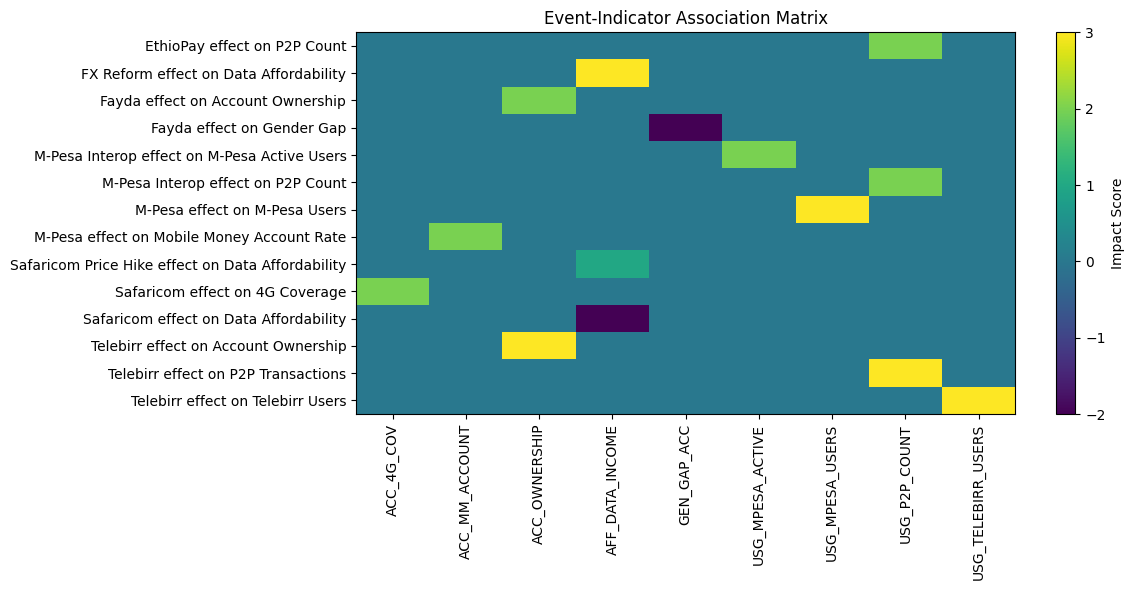

In [28]:
plt.figure(figsize=(12,6))

plt.imshow(
    association_matrix,
    aspect="auto"
)

plt.colorbar(label="Impact Score")

plt.xticks(
    range(len(association_matrix.columns)),
    association_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(association_matrix.index)),
    association_matrix.index
)

plt.title("Event-Indicator Association Matrix")

plt.tight_layout()

plt.show()

## 9. Time Decay Model

In [29]:
def event_effect(months_since_event,
                 lag,
                 strength):
    
    if months_since_event < lag:
        return 0
    
    progress = (
        months_since_event-lag
    )/12
    
    progress = min(progress,1)
    
    return strength*progress

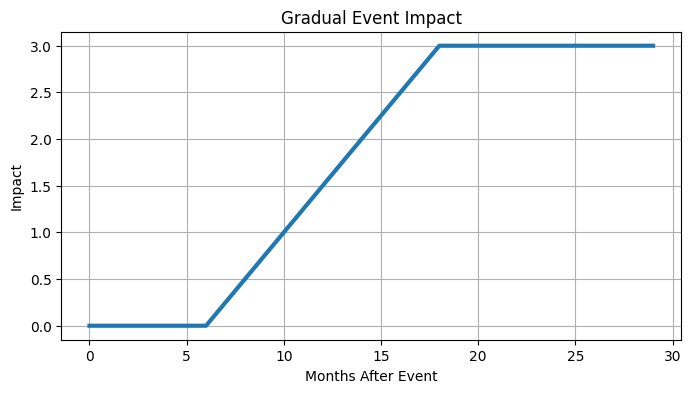

In [30]:
months = np.arange(0,30)

effect = [
    event_effect(
        m,
        lag=6,
        strength=3
    )
    for m in months
]

plt.figure(figsize=(8,4))

plt.plot(
    months,
    effect,
    linewidth=3
)

plt.xlabel("Months After Event")

plt.ylabel("Impact")

plt.title("Gradual Event Impact")

plt.grid(True)

plt.show()

## 10. Historical Validation

In [31]:
access = data[
    data["indicator_code"]=="ACC_MM_ACCOUNT"
].copy()

access.sort_values(
    "observation_date"
)

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
6,REC_0007,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,4.70,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
7,REC_0008,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,9.45,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Doubled from 2021,NaN


In [32]:
before = 4.7

after = 9.45

growth = after-before

growth

4.749999999999999

In [33]:
growth_percent = (
    growth/before
)*100

growth_percent

101.06382978723403

In [34]:
print("Observed increase:",growth)

print("Relative increase:",growth_percent,"%")

Observed increase: 4.749999999999999
Relative increase: 101.06382978723403 %


## 11. Refine Estimates

In [35]:
adjustments = pd.DataFrame({
    "event":[
        "Telebirr Launch",
        "M-Pesa Launch",
        "Fayda Expansion"
    ],
    "original_effect":[3,3,2],
    "revised_effect":[2.5,2.8,1.5],
    "reason":[
        "Growth slower than expected",
        "Short historical window",
        "Indirect enabling effect"
    ],
    "confidence":[
        "High",
        "Medium",
        "Medium"
    ]
})

adjustments

,event,original_effect,revised_effect,reason,confidence
0,Telebirr Launch,3,2.5,Growth slower than expected,High
1,M-Pesa Launch,3,2.8,Short historical window,Medium
2,Fayda Expansion,2,1.5,Indirect enabling effect,Medium


## 12. Methodology

- Modeling approach: Events were represented as time-dependent influences on financial inclusion indicators using impact links. Qualitative impact magnitudes (high, medium, low) were converted into numeric scores, and event effects were assumed to accumulate gradually after a specified lag period.

- Assumptions: Multiple events contribute additively to indicator changes; lag values approximate the delay before measurable effects appear; qualitative impact categories can be mapped to relative effect strengths.

- Validation: Estimated impacts were compared with historical changes in indicators such as mobile money account ownership after the Telebirr launch.

- Limitations: Limited historical observations, overlapping events that make attribution difficult, reliance on expert-assigned impact strengths, and the inability of the simple additive model to capture nonlinear interactions or broader macroeconomic influences.